# Aproximação de funções com MLP

Este notebook aproxima duas funções no intervalo [0, 5] usando um MLP com quatro camadas ocultas. O fluxo é: gerar dados, treinar, avaliar e visualizar.


## Importações

Numpy para cálculo numérico e Matplotlib para visualização dos ajustes e curvas de erro.


In [27]:
import numpy as np
import matplotlib.pyplot as plt

## Funções-alvo

Definição das duas funções que serão aproximadas no intervalo [0, 5].


In [28]:
def f1(x):
    return np.sin(2 * x) + np.cos(3 * x)


def f2(x):
    return 10 * x**5 + 5 * x**4 + 2 * x**3 - 0.5 * x**2 + 3 * x + 2


## MLP com quatro camadas ocultas

Implementação manual da rede com ativação tanh, incluindo propagação direta, predição e treino por gradiente descendente.


### Por que tanh em vez de sigmoid?

- A tanh é centrada em zero (-1 a 1), o que tende a manter gradientes mais equilibrados e acelerar o treino.
- A sigmoid satura mais cedo (próximo de 0 ou 1), gerando gradientes pequenos e aprendizado mais lento.
- Em regressão, tanh costuma funcionar melhor nas camadas ocultas quando os dados são normalizados/centrados.
- Sigmoid é mais indicada quando a saída precisa representar probabilidade (classificação binária).


In [29]:
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, seed=0):
        # Inicialização de pesos e vieses
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.5, size=(input_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.normal(0, 0.5, size=(hidden_dim, hidden_dim))
        self.b2 = np.zeros((1, hidden_dim))
        self.W3 = rng.normal(0, 0.5, size=(hidden_dim, hidden_dim))
        self.b3 = np.zeros((1, hidden_dim))
        self.W4 = rng.normal(0, 0.5, size=(hidden_dim, output_dim))
        self.b4 = np.zeros((1, output_dim))

    def forward(self, X):
        # Propagação direta com ativação tanh nas camadas ocultas
        Z1 = X @ self.W1 + self.b1
        A1 = np.tanh(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = np.tanh(Z2)
        Z3 = A2 @ self.W3 + self.b3
        A3 = np.tanh(Z3)
        Z4 = A3 @ self.W4 + self.b4
        return Z1, A1, Z2, A2, Z3, A3, Z4

    def predict(self, X):
        # Retorna apenas a saída da rede
        _, _, _, _, _, _, Z4 = self.forward(X)
        return Z4

    def fit(self, X_train, y_train, X_val, y_val, epochs=2000, lr=1e-3, seed=0):
        # Treino com gradiente descendente e validação a cada época
        rng = np.random.default_rng(seed)
        train_losses = []
        val_losses = []
        n = X_train.shape[0]
        for _ in range(epochs):
            # Embaralha os dados para cada época
            idx = rng.permutation(n)
            Xb = X_train[idx]
            yb = y_train[idx]

            # Forward + cálculo de erro
            Z1, A1, Z2, A2, Z3, A3, y_pred = self.forward(Xb)
            error = y_pred - yb
            loss = np.mean(error**2)

            dZ4 = 2 * error / n
            dW4 = A3.T @ dZ4
            db4 = np.sum(dZ4, axis=0, keepdims=True)

            dA3 = dZ4 @ self.W4.T
            dZ3 = dA3 * (1 - np.tanh(Z3) ** 2)
            dW3 = A2.T @ dZ3
            db3 = np.sum(dZ3, axis=0, keepdims=True)

            dA2 = dZ3 @ self.W3.T
            dZ2 = dA2 * (1 - np.tanh(Z2) ** 2)
            dW2 = A1.T @ dZ2
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = dZ2 @ self.W2.T
            dZ1 = dA1 * (1 - np.tanh(Z1) ** 2)
            dW1 = Xb.T @ dZ1
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            self.W4 -= lr * dW4
            self.b4 -= lr * db4
            self.W3 -= lr * dW3
            self.b3 -= lr * db3
            self.W2 -= lr * dW2
            self.b2 -= lr * db2
            self.W1 -= lr * dW1
            self.b1 -= lr * db1

            val_pred = self.predict(X_val)
            val_loss = np.mean((val_pred - y_val) ** 2)
            train_losses.append(loss)
            val_losses.append(val_loss)

        return np.array(train_losses), np.array(val_losses)

## Geração e divisão do dataset

Criação de amostras aleatórias no intervalo e separação em treino e validação.


In [30]:
def make_dataset(func, x_min=0.0, x_max=5.0, n_samples=400, seed=0):
    # Gera amostras aleatórias uniformes no intervalo desejado
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_min, x_max, size=(n_samples, 1))
    y = func(x)
    return x, y


def split_dataset(x, y, val_ratio=0.2, seed=0):
    # Divide em treino e validação
    rng = np.random.default_rng(seed)
    n = x.shape[0]
    idx = rng.permutation(n)
    split = int(n * (1 - val_ratio))
    train_idx = idx[:split]
    val_idx = idx[split:]
    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]


## Treino, avaliação e visualização

Treina a rede para cada função, calcula a acurácia (R²) na validação e plota a função real, a aproximação e as curvas de erro.


In [31]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1 - ss_res / ss_tot


def run_experiment(func, title, hidden_dim=50, epochs=3000, lr=1e-3, seed=0, normalize_y=False):
    x, y = make_dataset(func, seed=seed)
    x_train, y_train, x_val, y_val = split_dataset(x, y, seed=seed)

    if normalize_y:
        y_mean = np.mean(y_train, axis=0, keepdims=True)
        y_std = np.std(y_train, axis=0, keepdims=True)
        y_std = np.where(y_std == 0, 1.0, y_std)
        y_train_used = (y_train - y_mean) / y_std
        y_val_used = (y_val - y_mean) / y_std
    else:
        y_mean = 0.0
        y_std = 1.0
        y_train_used = y_train
        y_val_used = y_val

    mlp = MLP(1, hidden_dim, 1, seed=seed)
    train_losses, val_losses = mlp.fit(x_train, y_train_used, x_val, y_val_used, epochs=epochs, lr=lr, seed=seed)

    x_plot = np.linspace(0, 5, 500).reshape(-1, 1)
    y_true = func(x_plot)
    y_pred = mlp.predict(x_plot)
    if normalize_y:
        y_pred = y_pred * y_std + y_mean

    y_train_pred = mlp.predict(x_train)
    if normalize_y:
        y_train_pred = y_train_pred * y_std + y_mean
    r2_train = r2_score(y_train, y_train_pred)

    y_val_pred = mlp.predict(x_val)
    if normalize_y:
        y_val_pred = y_val_pred * y_std + y_mean
    r2_val = r2_score(y_val, y_val_pred)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x_plot, y_true, label="Função real")
    axes[0].plot(x_plot, y_pred, label="Aproximação")
    axes[0].scatter(x_val, y_val, s=10, alpha=0.3, label="Validação")
    axes[0].set_title(title)
    axes[0].legend()

    axes[1].plot(train_losses, label="Erro treino")
    axes[1].plot(val_losses, label="Erro validação")
    axes[1].set_title("Curvas de erro")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return r2_train, r2_val


## Resultados

Execução dos experimentos e impressão das acurácias de validação para cada função.


## Arquitetura de cada experimento

Resumo das arquiteturas usadas nos dois treinos do notebook, incluindo camadas, ativação e normalização.


In [32]:
def descrever_arquitetura(nome, input_dim, hidden_dim, output_dim, hidden_layers, ativacao, normalizacao):
    print(f"{nome}")
    print(f"Entrada: {input_dim}")
    for i in range(hidden_layers):
        print(f"Oculta {i + 1} ({ativacao}): {hidden_dim}")
    print(f"Saída: {output_dim}")
    print(f"Ativação: {ativacao}")
    print(f"Camadas ocultas: {hidden_layers}")
    print(f"Normalização de saída: {normalizacao}")
    print()


descrever_arquitetura(
    nome="Experimento f1",
    input_dim=1,
    hidden_dim=40,
    output_dim=1,
    hidden_layers=3,
    ativacao="tanh",
    normalizacao="não",
)

descrever_arquitetura(
    nome="Experimento f2",
    input_dim=1,
    hidden_dim=80,
    output_dim=1,
    hidden_layers=3,
    ativacao="tanh",
    normalizacao="sim (saída normalizada no treino)",
)


Experimento f1
Entrada: 1
Oculta 1 (tanh): 40
Oculta 2 (tanh): 40
Oculta 3 (tanh): 40
Saída: 1
Ativação: tanh
Camadas ocultas: 3
Normalização de saída: não

Experimento f2
Entrada: 1
Oculta 1 (tanh): 80
Oculta 2 (tanh): 80
Oculta 3 (tanh): 80
Saída: 1
Ativação: tanh
Camadas ocultas: 3
Normalização de saída: sim (saída normalizada no treino)



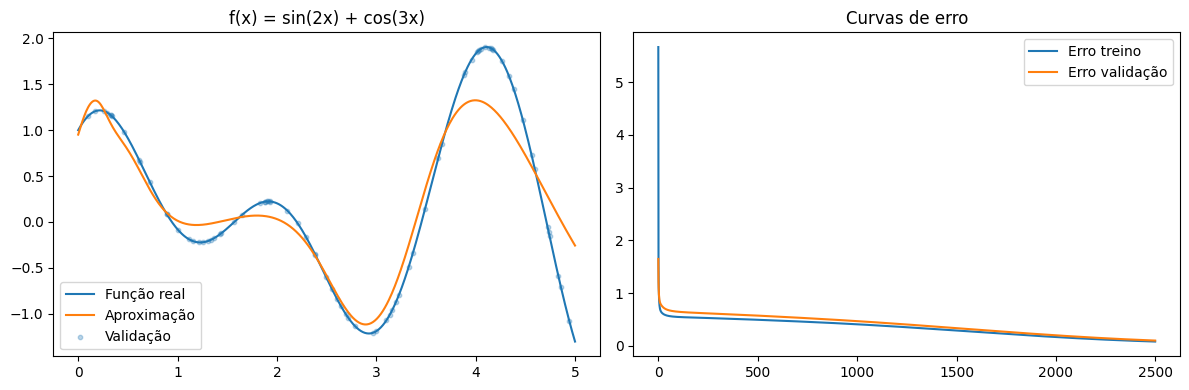

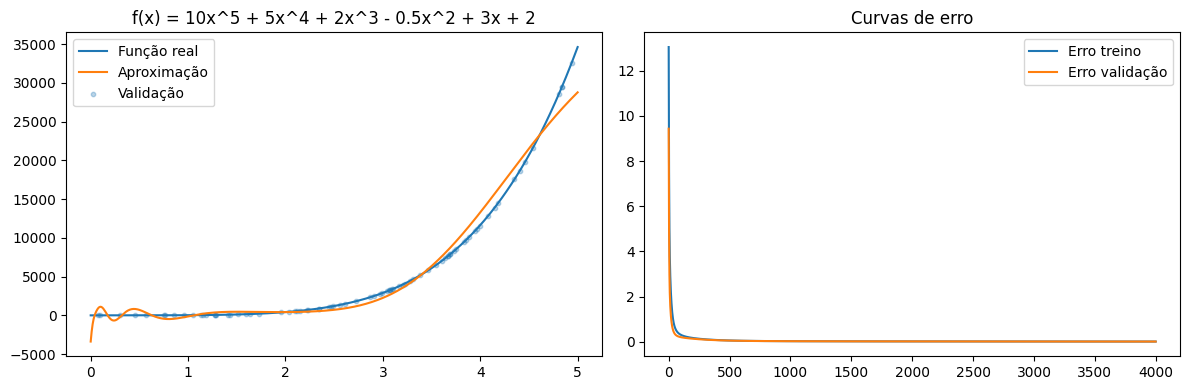

Acurácia (R²) f1 - treino: 0.8943
Acurácia (R²) f1 - validação: 0.8898
Acurácia (R²) f2 - treino: 0.9866
Acurácia (R²) f2 - validação: 0.9813


In [33]:
if __name__ == "__main__":
    r2_train_f1, r2_val_f1 = run_experiment(f1, "f(x) = sin(2x) + cos(3x)", hidden_dim=40, epochs=2500, lr=2e-3, seed=1)
    r2_train_f2, r2_val_f2 = run_experiment(f2, "f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2", hidden_dim=80, epochs=4000, lr=1e-4, seed=2, normalize_y=True)
    print(f"Acurácia (R²) f1 - treino: {r2_train_f1:.4f}")
    print(f"Acurácia (R²) f1 - validação: {r2_val_f1:.4f}")
    print(f"Acurácia (R²) f2 - treino: {r2_train_f2:.4f}")
    print(f"Acurácia (R²) f2 - validação: {r2_val_f2:.4f}")
